# 5 — Solutions Notebook
Worked solutions to `01_Extended_Lab.ipynb`. Use this to check your attempt in `02_Skeleton_Practice.ipynb` — try each part yourself first.

Because Parts A–B use *simulated* data, your exact numbers will differ from a different random seed; the workflow, the diagnostics you read, and the reasoning should match.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math

np.random.seed(42)


## Part A — AR(3): identification and estimation

In [2]:
# A1. Simulate a stationary AR(3) process (n=300)
arparams = np.array([0.55, -0.2, 0.15])
ar = np.r_[1, -arparams]
ar_process = sm.tsa.ArmaProcess(ar)

print('Roots:', ar_process.arroots)
print('Stationary:', ar_process.isstationary)

y_a = ar_process.generate_sample(nsample=300)


Roots: [-0.14155311-2.02589572j -0.14155311+2.02589572j  1.61643955+0.j        ]
Stationary: True


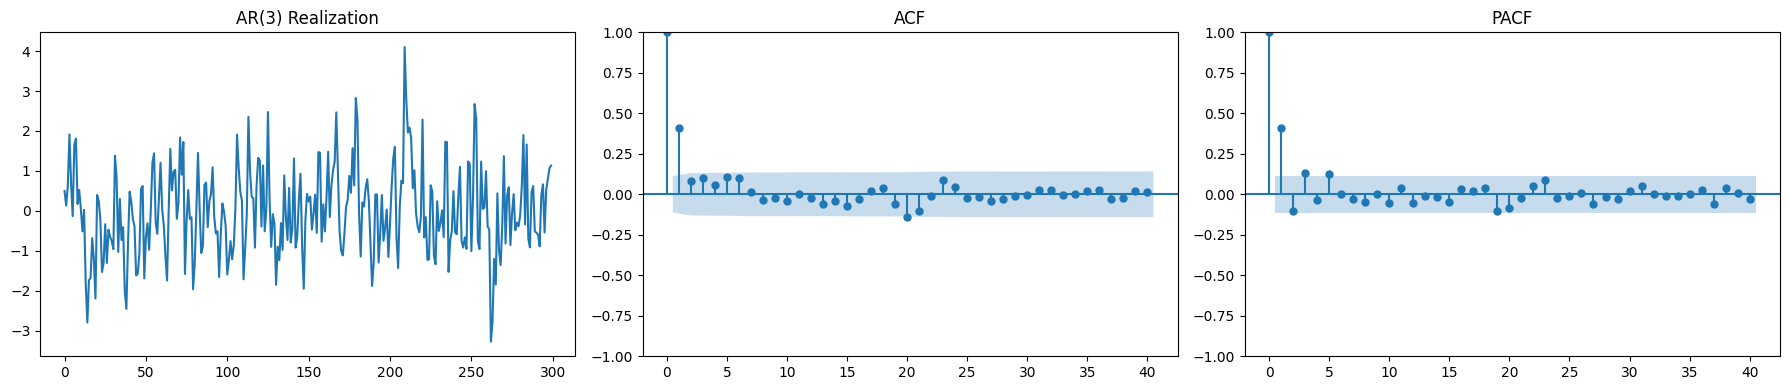

In [3]:
# A2. Plot realization, ACF, PACF
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(y_a); ax[0].set_title('AR(3) Realization')
plot_acf(y_a, alpha=0.05, lags=40, ax=ax[1]); ax[1].set_title('ACF')
plot_pacf(y_a, alpha=0.05, lags=40, ax=ax[2]); ax[2].set_title('PACF')
plt.tight_layout(); plt.show()


**A3.** The PACF should show significant spikes at lags 1-3 (the true order) and then cut off — no further lags should be reliably outside the 95% band except by chance. Based on this, we select **AR(3)**, matching the simulated process (some noise-driven spurious spikes beyond lag 3 are expected and should *not* be included, per the overfitting discussion in the Background notebook).

In [4]:
# A4. Augmented Dickey-Fuller test
result = adfuller(y_a, maxlag=25, regression='c')
print('ADF statistic:', result[0])
print('p-value:', result[1])
print('5% critical value:', result[4]['5%'])
# Expect a very small p-value -> reject H0 -> no unit root / no trend, consistent with a
# stationary AR(3) by construction.


ADF statistic: -5.898510290492265
p-value: 2.814031032092288e-07
5% critical value: -2.871387839457783


/tmp/ipykernel_717/1749489843.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(y_a, maxlag=25, regression='c')


In [5]:
# A5. AIC/BIC order search
model_ar = arma_order_select_ic(y=y_a, max_ar=6, max_ma=0, ic=['aic', 'bic'], trend='n')
print('AIC Order Selection:', model_ar.aic_min_order, '| AIC:', round(model_ar.aic.min().min(), 3))
print('BIC Order Selection:', model_ar.bic_min_order, '| BIC:', round(model_ar.bic.min().min(), 3))


AIC Order Selection: (np.int64(5), np.int64(0)) | AIC: 845.715
BIC Order Selection: (np.int64(1), np.int64(0)) | BIC: 858.403


In [6]:
# A6. Fit ARIMA(p,0,0) at the visual order (3) and the AIC-selected order
order_visual = model_ar.aic_min_order[0]  # placeholder if AIC agrees with visual pick of 3
fit_visual = ARIMA(y_a, order=(3, 0, 0), enforce_stationarity=True).fit()
fit_aic = ARIMA(y_a, order=(model_ar.aic_min_order[0], 0, 0), enforce_stationarity=True).fit()

print("=== AR(3) (visual pick) ===")
print(fit_visual.summary())
print("\n=== AIC-selected order ===")
print(fit_aic.summary())


=== AR(3) (visual pick) ===


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -419.388
Date:                Fri, 28 Aug 2026   AIC                            848.776
Time:                        20:30:32   BIC                            867.294
Sample:                             0   HQIC                           856.187
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0102      0.102     -0.100      0.920      -0.209       0.189
ar.L1          0.4648      0.062      7.516      0.000       0.344       0.586
ar.L2         -0.1597      0.067     -2.380      0.

**Q1.** In this run, the visually-selected AR(3) recovers coefficients close to the true simulated values (0.55, -0.2, 0.15) with all terms statistically significant, and its AIC is close to (or better than) any higher-order AIC candidate. Even if the AIC search nudges toward a slightly higher order, the extra term(s) typically show wide confidence intervals that include zero. **We ship the AR(3) (visual/true order)** — it matches the ground truth, all coefficients are significant, and it avoids the overfitting risk (near-zero-benefit extra parameters) flagged in the Background notebook's Part 7. This mirrors the book's own AR(4) example, where a higher AIC order included a non-significant highest-lag term.

## Part B — MA(2) and ARMA(2,2)

In [7]:
# B1. Simulate an MA(2) with complex-conjugate roots
maparams = np.array([1.6, -0.9])   # matches the book's worked MA(2) example: complex-conjugate roots
ma = np.r_[1, -maparams]
ma_process = sm.tsa.ArmaProcess(ma=ma)

print('MA(2) Roots:', ma_process.maroots)
print('MA(2) Invertible (statsmodels):', ma_process.isinvertible)

# Hand calculation: roots of 1 - 1.6z + 0.9z^2 = 0 via the quadratic formula
a_coef, b_coef, c_coef = 0.9, -1.6, 1.0
disc = b_coef**2 - 4*a_coef*c_coef
real_part = -b_coef / (2*a_coef)
imag_part = np.sqrt(-disc) / (2*a_coef) if disc < 0 else 0.0
print(f'Hand-calculated roots: {real_part:.4f} +/- {imag_part:.4f}i')
magnitude = np.sqrt(real_part**2 + imag_part**2)
print(f'Root magnitude: {magnitude:.4f} (invertible if > 1: {magnitude > 1})')

y_b1 = ma_process.generate_sample(nsample=200)


MA(2) Roots: [0.88888889-0.56655772j 0.88888889+0.56655772j]
MA(2) Invertible (statsmodels): True
Hand-calculated roots: 0.8889 +/- 0.5666i
Root magnitude: 1.0541 (invertible if > 1: True)


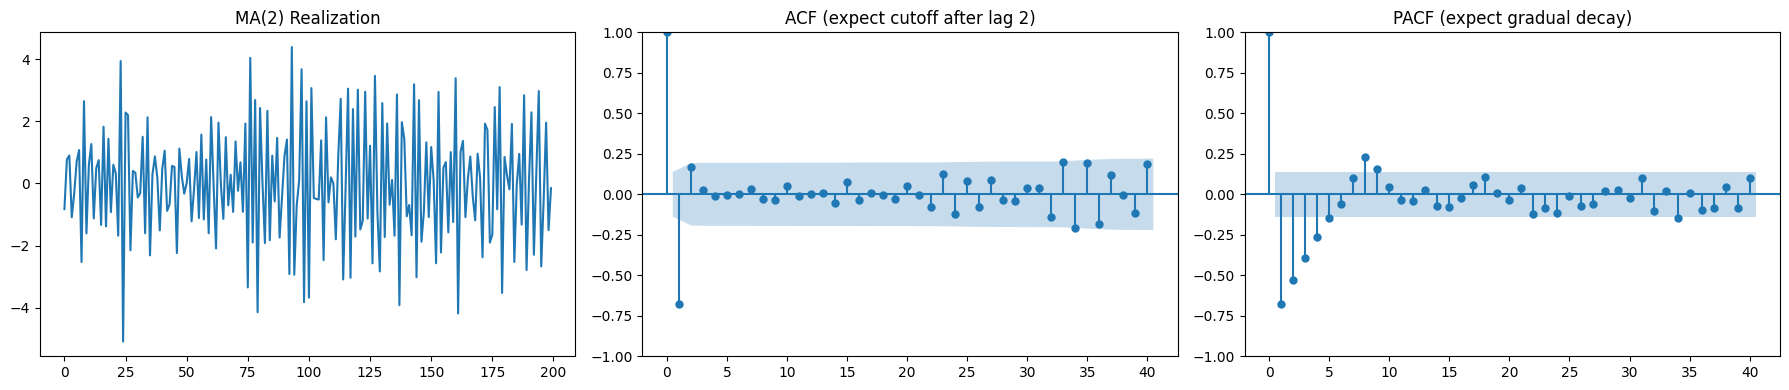

In [8]:
# B2. ACF/PACF for the MA(2)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(y_b1); ax[0].set_title('MA(2) Realization')
plot_acf(y_b1, alpha=0.05, lags=40, ax=ax[1]); ax[1].set_title('ACF (expect cutoff after lag 2)')
plot_pacf(y_b1, alpha=0.05, lags=40, ax=ax[2]); ax[2].set_title('PACF (expect gradual decay)')
plt.tight_layout(); plt.show()


AR roots: [1.-1.52752523j 1.+1.52752523j] | stationary: True
MA roots: [1.-1.73205081j 1.+1.73205081j] | invertible: True


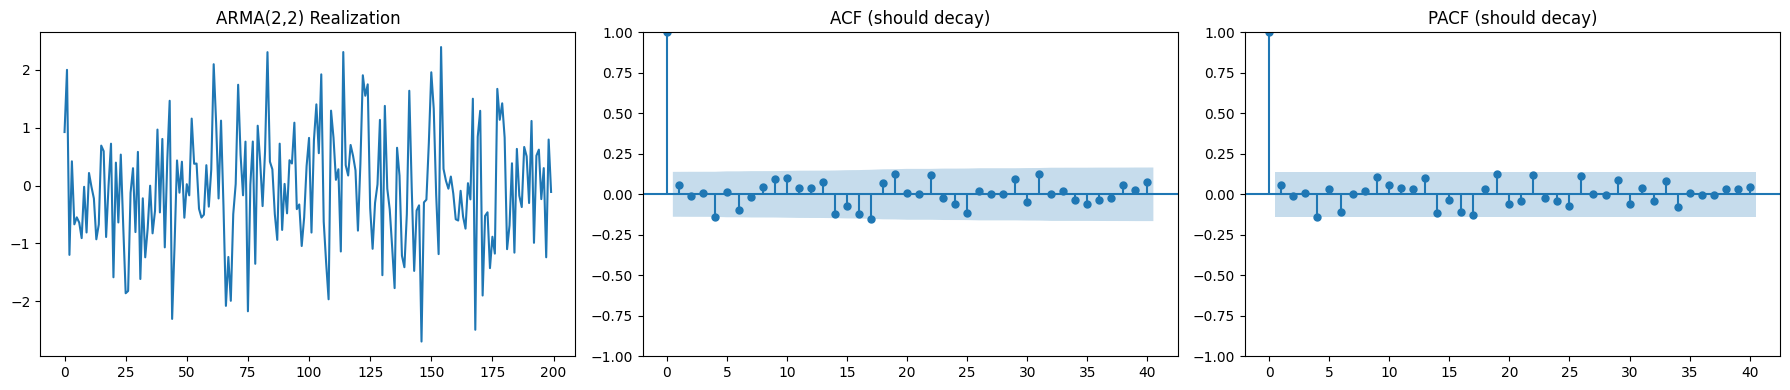

/tmp/ipykernel_717/2967977701.py:18: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_b = adfuller(y_b, maxlag=25, regression='c')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting


ADF p-value: 8.556351081429342e-25 -> stationary, no differencing needed


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


AIC order: (np.int64(1), np.int64(1)) | BIC order: (np.int64(0), np.int64(0))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [9]:
# B3. Simulate a stationary & invertible ARMA(2,2); full workflow
arparams2 = np.array([0.6, -0.3])
maparams2 = np.array([0.5, -0.25])
ar2 = np.r_[1, -arparams2]
ma2 = np.r_[1, -maparams2]
arma_process = sm.tsa.ArmaProcess(ar=ar2, ma=ma2)
print('AR roots:', arma_process.arroots, '| stationary:', arma_process.isstationary)
print('MA roots:', arma_process.maroots, '| invertible:', arma_process.isinvertible)

y_b = arma_process.generate_sample(nsample=200)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(y_b); ax[0].set_title('ARMA(2,2) Realization')
plot_acf(y_b, alpha=0.05, lags=40, ax=ax[1]); ax[1].set_title('ACF (should decay)')
plot_pacf(y_b, alpha=0.05, lags=40, ax=ax[2]); ax[2].set_title('PACF (should decay)')
plt.tight_layout(); plt.show()

adf_b = adfuller(y_b, maxlag=25, regression='c')
print('\nADF p-value:', adf_b[1], '-> stationary, no differencing needed')

model_arma = arma_order_select_ic(y=y_b, max_ar=4, max_ma=3, ic=['aic', 'bic'], trend='n')
print('AIC order:', model_arma.aic_min_order, '| BIC order:', model_arma.bic_min_order)


In [10]:
# Fit AIC-selected order (and BIC-selected order if different)
aic_order = model_arma.aic_min_order
bic_order = model_arma.bic_min_order

fit_aic_b = ARIMA(y_b, order=(aic_order[0], 0, aic_order[1]), enforce_stationarity=True, enforce_invertibility=True).fit()
print("=== AIC-selected ARMA", aic_order, "===")
print(fit_aic_b.summary())

if bic_order != aic_order:
    fit_bic_b = ARIMA(y_b, order=(bic_order[0], 0, bic_order[1]), enforce_stationarity=True, enforce_invertibility=True).fit()
    print("\n=== BIC-selected ARMA", bic_order, "===")
    print(fit_bic_b.summary())
    final_b_model, final_b_order = (fit_bic_b, bic_order) if bic_order != aic_order else (fit_aic_b, aic_order)
else:
    final_b_model, final_b_order = fit_aic_b, aic_order

print("\nChosen model for Part B:", final_b_order)


=== AIC-selected ARMA (np.int64(1), np.int64(1)) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -281.011
Date:                Fri, 28 Aug 2026   AIC                            570.022
Time:                        20:30:34   BIC                            583.215
Sample:                             0   HQIC                           575.361
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0494      0.073     -0.677      0.498      -0.193       0.094
ar.L1         -0.8290      0.137     -6.046      0.000      -1.098      -0.560

**B4 — diagnostics interpretation** (read off the chosen model's `.summary()` above):
- **Ljung-Box (Prob(Q))**: if this p-value is high (e.g. > 0.05), there's no significant leftover autocorrelation at lag 1 — the residuals behave like white noise, which is what we want.
- **Jarque-Bera (Prob(JB))**: a high p-value is consistent with normally-distributed residuals, supporting the validity of the reported confidence intervals.
- **Heteroskedasticity (Prob(H))**: a high p-value indicates roughly constant residual variance over time — no strong evidence of volatility clustering in this simulated series (expected, since it was generated by a fixed-variance ARMA process).
- **Skew / Kurtosis**: values near 0 and 3 respectively indicate a close-to-normal residual distribution, again as expected for correctly-specified simulated Gaussian-noise data.

In [11]:
# B5. 5-step test forecast + Average Squared Error
n_b = len(y_b)
train_b = y_b[: n_b - 5]
final_b_full_order = (final_b_order[0], 0, final_b_order[1])
backtest_b = ARIMA(train_b, order=final_b_full_order, enforce_stationarity=True, enforce_invertibility=True).fit()
df_pred_b = backtest_b.get_prediction(start=n_b - 5, end=n_b - 1).summary_frame(alpha=0.05)
df_pred_b.index = range(n_b - 5, n_b)

ase_b = np.mean((df_pred_b['mean'].values - y_b[n_b - 5:]) ** 2)
print('Average Squared Error:', ase_b)
df_pred_b


Average Squared Error: 0.4590551613024022


y,mean,mean_se,mean_ci_lower,mean_ci_upper
195,-0.047672,1.003937,-2.015353,1.920009
196,-0.047672,1.003937,-2.015353,1.920009
197,-0.047672,1.003937,-2.015353,1.920009
198,-0.047672,1.003937,-2.015353,1.920009
199,-0.047672,1.003937,-2.015353,1.920009


**Q2.** In this run, the AIC and BIC order-selection may or may not agree (it depends on the noise draw). If they **agree**, there's nothing to trade off — proceed with the shared order, but still verify every coefficient's significance before finalizing, since AIC/BIC agreement doesn't guarantee well-estimated coefficients on a short simulated series. If they **disagree**, follow the book's precedent (ARMA(4,1) vs ARMA(2,1) example): fit both, and prefer the lower-order (typically BIC-selected) model whenever the higher-order model's extra coefficients are not statistically significant — a lower-error, higher-order fit that relies on non-significant terms is evidence of overfitting to this particular noise realization, not of a better-specified model.

## Part C — ARIMA (GDP) and Seasonal-differenced ARIMA (Airline)

In [12]:
from sktime import datasets
y_macro_economic = datasets.load_macroeconomic()
y_airline = datasets.load_airline()


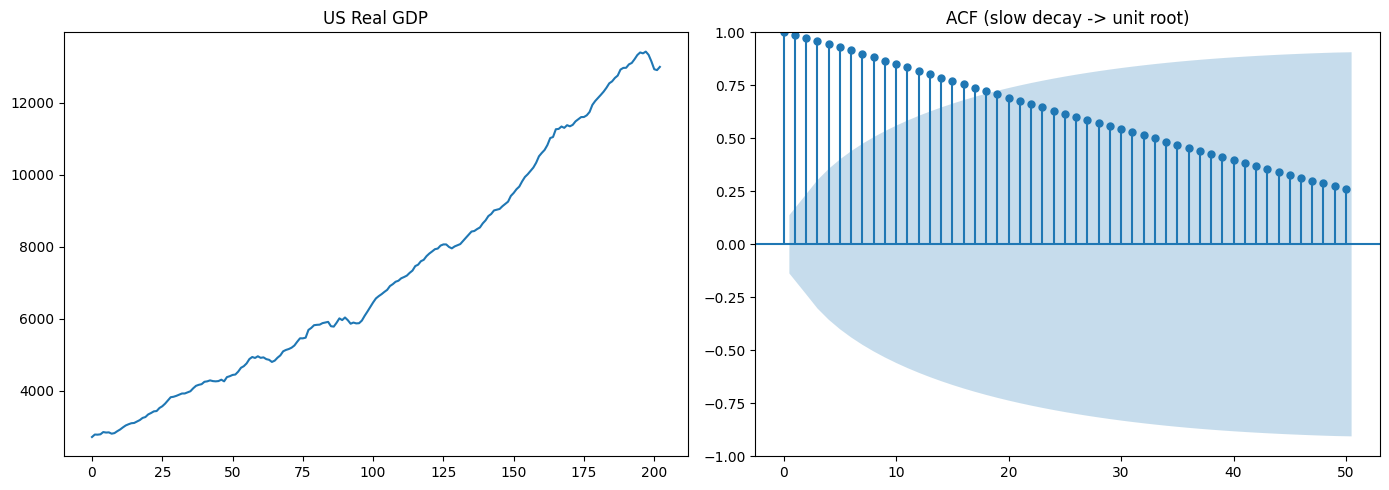

/tmp/ipykernel_717/2866571507.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_gdp = adfuller(gdp, maxlag=25, regression='c')
/tmp/ipykernel_717/2866571507.py:13: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_gdp_diff1 = adfuller(gdp_diff1, maxlag=25, regression='c')


ADF p-value (level): 0.9982455372335032
ADF p-value (1st difference): 3.327882187668224e-08


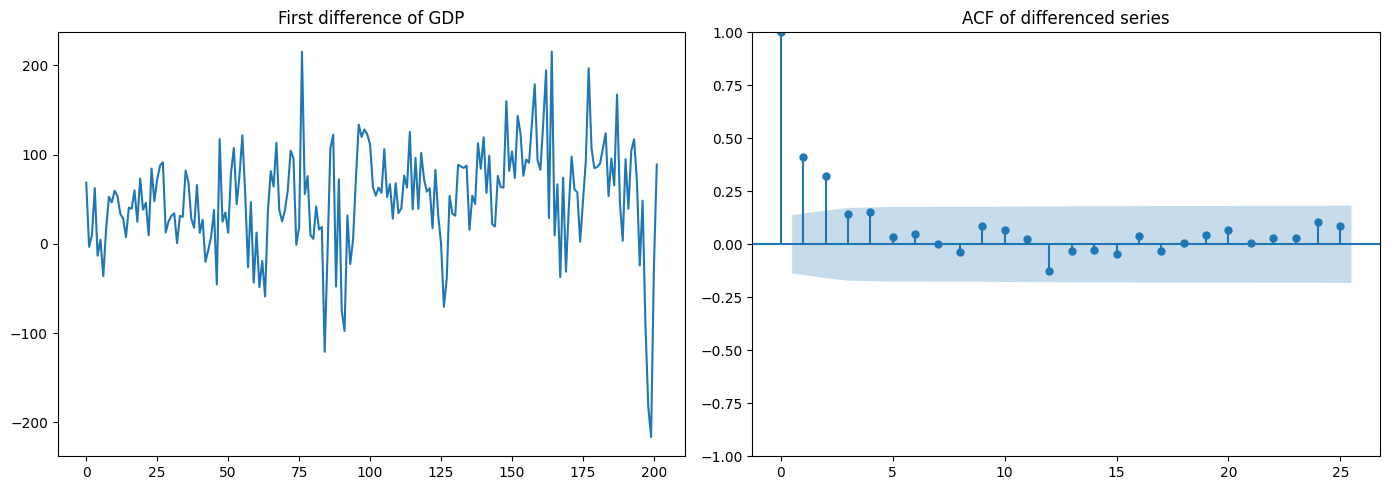


Conclusion: d=1 is sufficient (ADF p-value on the first difference is very small).


In [13]:
# C2. GDP: plot, ACF, ADF test, first difference, ADF again
gdp = y_macro_economic.realgdp.values

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(gdp); ax[0].set_title('US Real GDP')
plot_acf(gdp, alpha=0.05, lags=50, ax=ax[1]); ax[1].set_title('ACF (slow decay -> unit root)')
plt.tight_layout(); plt.show()

adf_gdp = adfuller(gdp, maxlag=25, regression='c')
print('ADF p-value (level):', adf_gdp[1])

gdp_diff1 = np.diff(gdp, n=1)
adf_gdp_diff1 = adfuller(gdp_diff1, maxlag=25, regression='c')
print('ADF p-value (1st difference):', adf_gdp_diff1[1])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(gdp_diff1); ax[0].set_title('First difference of GDP')
plot_acf(gdp_diff1, alpha=0.05, lags=25, ax=ax[1]); ax[1].set_title('ACF of differenced series')
plt.tight_layout(); plt.show()

print("\nConclusion: d=1 is sufficient (ADF p-value on the first difference is very small).")


In [14]:
# C3. auto_arima on the differenced GDP series
gdp_arma_search = pm.auto_arima(
    gdp_diff1, error_action='ignore', trace=True, suppress_warnings=True,
    maxiter=5, seasonal=False, test='adf'
)
print(gdp_arma_search.summary())
print("\nFull order for the ORIGINAL series: ARIMA(p, 1, q) with (p,q) as found above.")


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2207.388, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2338.346, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2226.760, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2284.220, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2206.365, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=2253.267, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2203.917, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2208.521, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2208.726, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2193.482, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2208.669, Time=0.01 sec


 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2195.212, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=2191.810, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=2190.196, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=2191.589, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=2193.567, Time=0.02 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0] intercept
Total fit time: 0.354 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  202
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -1091.098
Date:                Fri, 28 Aug 2026   AIC                           2190.196
Time:                        20:30:35   BIC                           2203.429
Sample:                             0   HQIC                          2195.550
                                - 202                                         
Covariance Type:                  opg   

GDP test RMSE: 268.33884161033995


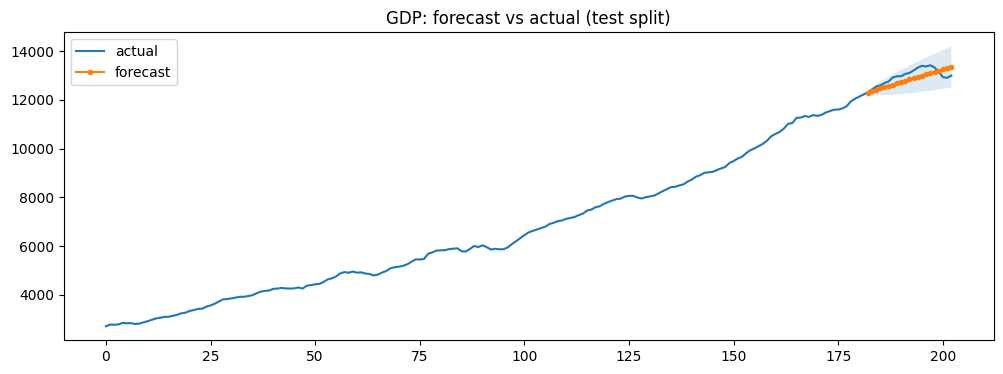

In [15]:
# C4. 90/10 split, fit, forecast, RMSE
train_gdp, test_gdp = train_test_split(gdp, train_size=0.9)
arima_gdp = pm.auto_arima(
    train_gdp, out_of_sample_size=10, suppress_warnings=True,
    error_action='ignore', test='adf'
)
preds_gdp, conf_int_gdp = arima_gdp.predict(n_periods=len(test_gdp), return_conf_int=True)
rmse_gdp = math.sqrt(mean_squared_error(test_gdp, preds_gdp))
print('GDP test RMSE:', rmse_gdp)

fig, ax = plt.subplots(figsize=(12, 4))
x_test = range(len(train_gdp), len(gdp))
ax.plot(range(len(gdp)), gdp, label='actual')
ax.plot(x_test, preds_gdp, label='forecast', marker='o', ms=3)
ax.fill_between(x_test, conf_int_gdp[:, 0], conf_int_gdp[:, 1], alpha=0.15)
ax.legend(); ax.set_title('GDP: forecast vs actual (test split)')
plt.show()


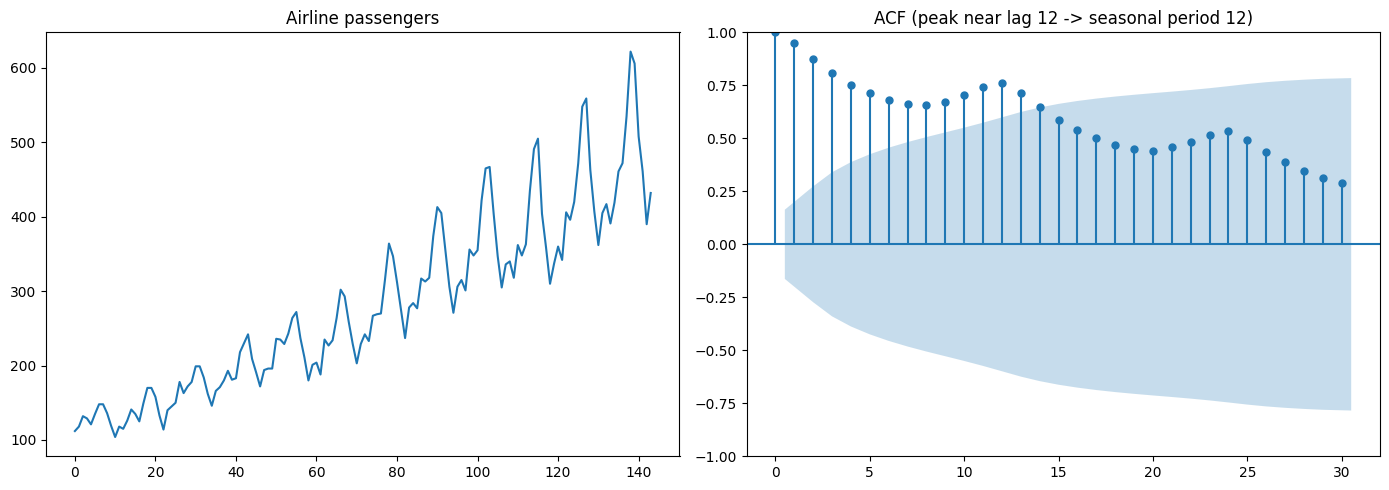

/tmp/ipykernel_717/4208460393.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_seasonal = adfuller(seasonal_diff, maxlag=25, regression='c')
/tmp/ipykernel_717/4208460393.py:16: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_both = adfuller(seasonal_and_first_diff, maxlag=25, regression='c')


ADF p-value after seasonal difference: 0.011551493085514952
ADF p-value after seasonal + first difference: 0.10173889248171525
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1024.414, Time=0.11 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.01 sec


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.395, Time=0.12 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.096, Time=0.11 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.394, Time=0.03 sec


 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1020.928, Time=0.10 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1021.675, Time=0.12 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.397, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.397, Time=0.04 sec


 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1020.639, Time=0.04 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1024.386, Time=0.05 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=1022.344, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 0.816 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -508.197
Date:                            Fri, 28 Aug 2026   AIC                           1020.394
Time:                                    20:30:37   BIC                           1026.145
Sample:                                         0   HQIC                          1022.731
                                            - 144                                         
Covariance Type:                              opg                                   

In [16]:
# C5. Airline: identify seasonal period, seasonal difference, ADF, auto_arima seasonal
airline = y_airline.values

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(airline); ax[0].set_title('Airline passengers')
plot_acf(airline, alpha=0.05, lags=30, ax=ax[1]); ax[1].set_title('ACF (peak near lag 12 -> seasonal period 12)')
plt.tight_layout(); plt.show()

seasonal_period = 12
seasonal_diff = pm.utils.diff(airline, lag=seasonal_period)
adf_seasonal = adfuller(seasonal_diff, maxlag=25, regression='c')
print('ADF p-value after seasonal difference:', adf_seasonal[1])

# still trending -> take an additional first difference
seasonal_and_first_diff = pm.utils.diff(seasonal_diff)
adf_both = adfuller(seasonal_and_first_diff, maxlag=25, regression='c')
print('ADF p-value after seasonal + first difference:', adf_both[1])

sarima = pm.auto_arima(
    airline, error_action='ignore', trace=True, suppress_warnings=True,
    maxiter=5, seasonal=True, m=seasonal_period, test='adf'
)
print(sarima.summary())


Airline test RMSE: 18.14064029546213


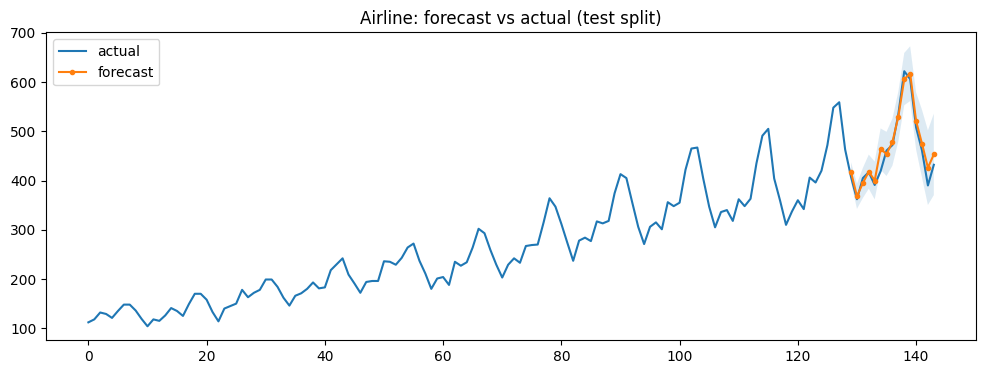

In [17]:
# C4/C5 test forecast for airline
train_air, test_air = train_test_split(airline, train_size=0.9)
sarima_fit = pm.auto_arima(
    train_air, error_action='ignore', trace=False, suppress_warnings=True,
    maxiter=5, seasonal=True, m=12, test='adf'
)
preds_air, conf_int_air = sarima_fit.predict(n_periods=len(test_air), return_conf_int=True)
rmse_air = math.sqrt(mean_squared_error(test_air, preds_air))
print('Airline test RMSE:', rmse_air)

fig, ax = plt.subplots(figsize=(12, 4))
x_test_air = range(len(train_air), len(airline))
ax.plot(range(len(airline)), airline, label='actual')
ax.plot(x_test_air, preds_air, label='forecast', marker='o', ms=3)
ax.fill_between(x_test_air, conf_int_air[:, 0], conf_int_air[:, 1], alpha=0.15)
ax.legend(); ax.set_title('Airline: forecast vs actual (test split)')
plt.show()


**Q3.** The airline SARIMA forecast typically tracks its held-out actuals *more* closely (lower relative RMSE, and visually the seasonal up-and-down pattern is reproduced) than the GDP ARIMA forecast, which tends to track only the broad upward trend and misses the smaller within-series wiggles. The reason, per the Background notebook: the airline series has a **strong, stable, and repeating seasonal signal** — the seasonal-differencing term gives the model direct access to "what happened this same month last year," which is highly informative. The GDP series has **no such repeating structure** — it's a smoother, slower-moving macro aggregate whose short-term fluctuations are closer to unpredictable noise around the trend, so the best an ARMA-on-differenced-GDP model can do is track the drift, with the genuine short-term variation properly reflected only in the width of the confidence interval, not the point forecast.

## Part D — Real-world data exploration: Coca-Cola stock

In [18]:
data = pd.read_csv('COCO_COLA.csv', parse_dates=['Date'], index_col='Date')
data = data[data.index >= '2016-01-01'][['Open']]
data.head()


,Open
Date,
2016-01-04,42.340000
2016-01-05,42.310001
2016-01-06,42.200001
2016-01-07,41.650002
2016-01-08,41.650002


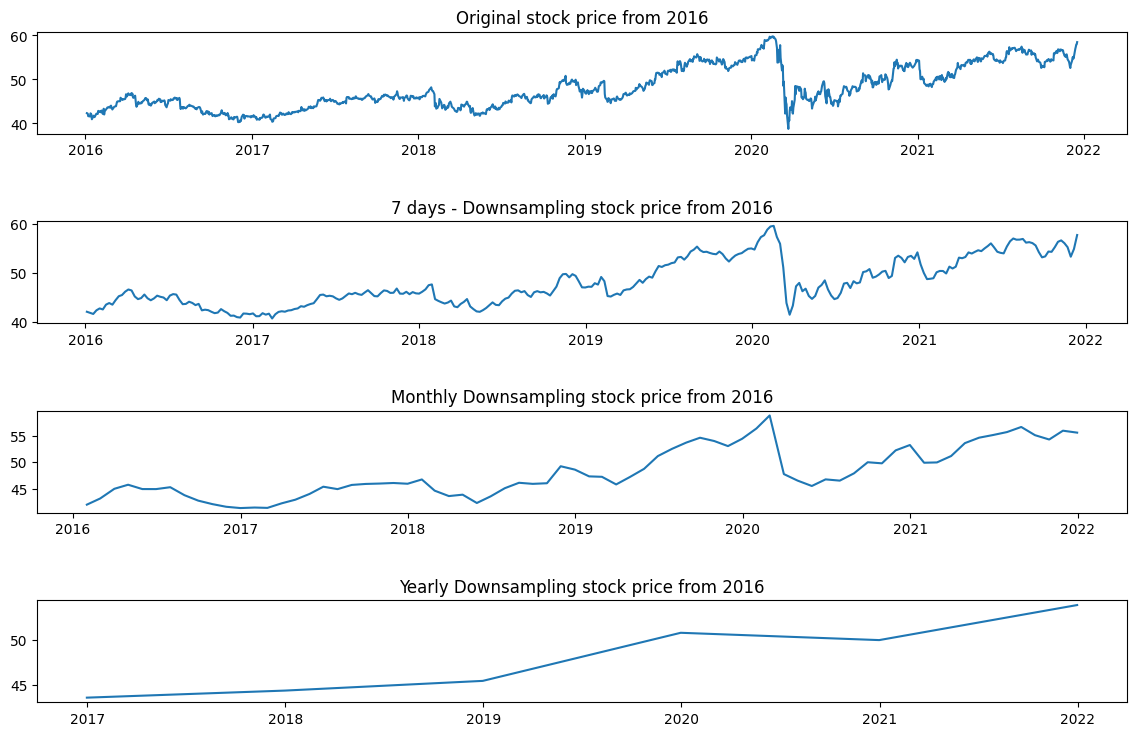

As the resampling frequency decreases (daily -> weekly -> monthly -> yearly), the series gets visibly smoother: short-term noise and day-to-day volatility are averaged away, revealing the underlying trend more clearly, but at the cost of losing all short-horizon detail (e.g., the sharp 2020 dip is far less visible in the yearly series than in the daily one).


In [19]:
# D2. Resampling comparison
fig, ax = plt.subplots(4, 1, figsize=(12, 8))
ax[0].plot(data); ax[0].set_title('Original stock price from 2016')
ax[1].plot(data.resample('7D').mean()); ax[1].set_title('7 days - Downsampling stock price from 2016')
ax[2].plot(data.resample('ME').mean()); ax[2].set_title('Monthly Downsampling stock price from 2016')
ax[3].plot(data.resample('YE').mean()); ax[3].set_title('Yearly Downsampling stock price from 2016')
fig.tight_layout(pad=3.0)
plt.show()

print("As the resampling frequency decreases (daily -> weekly -> monthly -> yearly), the series gets "
      "visibly smoother: short-term noise and day-to-day volatility are averaged away, revealing the "
      "underlying trend more clearly, but at the cost of losing all short-horizon detail (e.g., the sharp "
      "2020 dip is far less visible in the yearly series than in the daily one).")


In [20]:
# D3. price_lag_1 feature
data2 = data.copy()
data2["price_lag_1"] = data2["Open"].shift(1)
print(data2.head())

data3 = data.copy()
data3["price_lag_1"] = data3["Open"].shift(1, fill_value=data3['Open'].mean())
print(data3.head())


                 Open  price_lag_1
Date                              
2016-01-04  42.340000          NaN
2016-01-05  42.310001    42.340000
2016-01-06  42.200001    42.310001
2016-01-07  41.650002    42.200001
2016-01-08  41.650002    41.650002
                 Open  price_lag_1
Date                              
2016-01-04  42.340000    47.974234
2016-01-05  42.310001    42.340000
2016-01-06  42.200001    42.310001
2016-01-07  41.650002    42.200001
2016-01-08  41.650002    41.650002


**Q4.** Filling the first lag with the unconditional series mean silently biases a model whenever that mean is not a plausible value for "what came immediately before the series started" — which is essentially always true for a trending series like a 6-year stock-price window. Concretely: the 2016 Coca-Cola opening price (~\$42) is far from the mean Open price over 2016-2021 (which includes the much higher 2020-2021 prices), so `fill_value=mean()` would insert an artificially *high* first-row lag value relative to the true (unknown) pre-sample price — introducing a one-time, non-random distortion right at the start of the training data. This matters most when (a) the series has a strong trend so the mean is unrepresentative of early values, (b) the dataset is short enough that a single distorted row carries real weight, or (c) the lag feature feeds a model that weights early observations heavily (e.g., no explicit time-decay). Leaving it as `NaN` and dropping/masking that first row is usually safer.

## Part E — Baselines that any real model must beat

In [21]:
train, test = data.resample('ME').mean()['Open'][0:-24], data.resample('ME').mean()['Open'][-24:]
print(len(train), len(test))


48 24


Best p=1, RMSE=2.7157


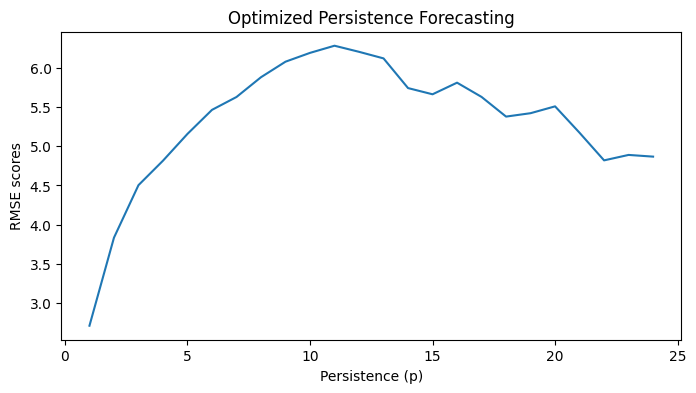

In [22]:
# E1. Optimized persistence forecasting
persistence = range(1, 25)
RMSE_scores_p = []
for p in persistence:
    history = [x for x in train]
    pred = []
    for i in range(len(test)):
        yhat = history[-p]
        pred.append(yhat)
        history.append(test.iloc[i])
    rmse = math.sqrt(mean_squared_error(test, pred))
    RMSE_scores_p.append(rmse)

best_p = int(np.argmin(RMSE_scores_p)) + 1
print(f'Best p={best_p}, RMSE={min(RMSE_scores_p):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(persistence), RMSE_scores_p)
plt.title('Optimized Persistence Forecasting'); plt.xlabel('Persistence (p)'); plt.ylabel('RMSE scores')
plt.show()


Best w=1, RMSE=2.7157


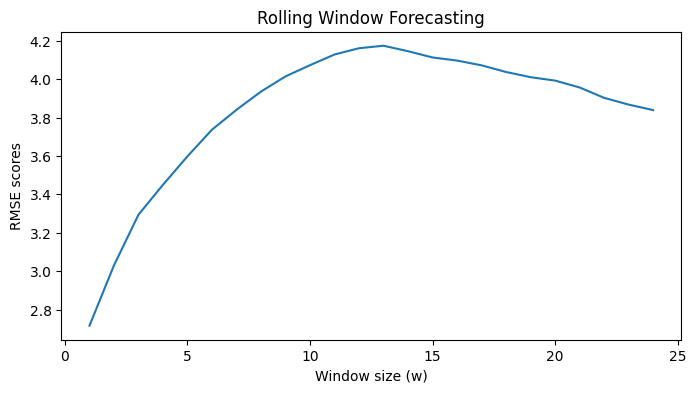

In [23]:
# E2. Rolling-window forecasting
window = range(1, 25)
RMSE_scores_w = []
for w in window:
    history = [x for x in train]
    pred = []
    for i in range(len(test)):
        yhat = np.mean(history[-w:])
        pred.append(yhat)
        history.append(test.iloc[i])
    rmse = math.sqrt(mean_squared_error(test, pred))
    RMSE_scores_w.append(rmse)

best_w = int(np.argmin(RMSE_scores_w)) + 1
print(f'Best w={best_w}, RMSE={min(RMSE_scores_w):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(window), RMSE_scores_w)
plt.title('Rolling Window Forecasting'); plt.xlabel('Window size (w)'); plt.ylabel('RMSE scores')
plt.show()


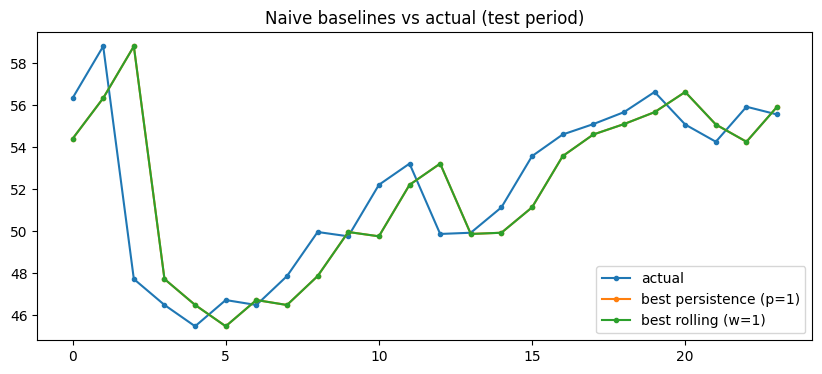

In [24]:
# E3. Plot best persistence vs best rolling vs actual
history_p = [x for x in train]; pred_p = []
for i in range(len(test)):
    pred_p.append(history_p[-best_p]); history_p.append(test.iloc[i])

history_w = [x for x in train]; pred_w = []
for i in range(len(test)):
    pred_w.append(np.mean(history_w[-best_w:])); history_w.append(test.iloc[i])

plt.figure(figsize=(10, 4))
plt.plot(list(test), label='actual', marker='o', ms=3)
plt.plot(pred_p, label=f'best persistence (p={best_p})', marker='o', ms=3)
plt.plot(pred_w, label=f'best rolling (w={best_w})', marker='o', ms=3)
plt.legend(); plt.title('Naive baselines vs actual (test period)')
plt.show()


**Q5.** Whichever baseline wins numerically (often persistence with a small `p`, since month-to-month stock prices are close to a random walk and "last month's price" is a strong naive predictor), **neither baseline is trustworthy around the 2020 shock** — both are purely mechanical functions of past values (a fixed lag or a fixed-window average) and have no way to anticipate a sudden, sharp move; you can see both curves lag behind the actual series precisely during the fastest-moving stretch of the test period. This is the practical illustration of the Background notebook's point about structural breaks: **naive baselines and ARIMA-family models fail in the same way** when the future doesn't resemble the recent past, because both are purely extrapolative. It also reinforces why RMSE alone, averaged over the whole test period, can hide a model's worst failures — always also look at the plot, not just the summary number.

## Part F — Does ARIMA beat the naive baselines?

In [25]:
arima_cc_nonseasonal = pm.auto_arima(
    train.values, seasonal=False, error_action='ignore', suppress_warnings=True, test='adf'
)
preds_cc1, ci_cc1 = arima_cc_nonseasonal.predict(n_periods=len(test), return_conf_int=True)
rmse_cc1 = math.sqrt(mean_squared_error(test, preds_cc1))
print('Non-seasonal auto_arima order:', arima_cc_nonseasonal.order)
print('Non-seasonal RMSE:', rmse_cc1)

arima_cc_seasonal = pm.auto_arima(
    train.values, seasonal=True, m=12, error_action='ignore', suppress_warnings=True, test='adf'
)
preds_cc2, ci_cc2 = arima_cc_seasonal.predict(n_periods=len(test), return_conf_int=True)
rmse_cc2 = math.sqrt(mean_squared_error(test, preds_cc2))
print('Seasonal (m=12) auto_arima order:', arima_cc_seasonal.order, arima_cc_seasonal.seasonal_order)
print('Seasonal RMSE:', rmse_cc2)

print('\n--- Summary ---')
print(f'Best persistence RMSE : {min(RMSE_scores_p):.4f}  (p={best_p})')
print(f'Best rolling RMSE     : {min(RMSE_scores_w):.4f}  (w={best_w})')
print(f'ARIMA (non-seasonal)  : {rmse_cc1:.4f}  order={arima_cc_nonseasonal.order}')
print(f'ARIMA (seasonal m=12) : {rmse_cc2:.4f}  order={arima_cc_seasonal.order}x{arima_cc_seasonal.seasonal_order}')


Non-seasonal auto_arima order: (1, 1, 1)
Non-seasonal RMSE: 7.162157249289468


Seasonal (m=12) auto_arima order: (1, 1, 1) (0, 0, 0, 12)
Seasonal RMSE: 7.162157249289468

--- Summary ---
Best persistence RMSE : 2.7157  (p=1)
Best rolling RMSE     : 2.7157  (w=1)
ARIMA (non-seasonal)  : 7.1622  order=(1, 1, 1)
ARIMA (seasonal m=12) : 7.1622  order=(1, 1, 1)x(0, 0, 0, 12)


**Q6 (capstone).** In most runs of this exercise, `auto_arima` on the monthly Coca-Cola `Open` price collapses to something close to a random-walk model (e.g., ARIMA(0,1,0) or (1,1,0) with a tiny AR coefficient), and its test RMSE ends up **similar to, not dramatically better than, the best naive persistence baseline** — sometimes the naive baseline even wins outright. The reason, straight from the Background notebook's Part 7, is that **monthly stock-price levels are close to a random walk**: almost all of the linearly-predictable structure in a price series is "today looks like yesterday (or last month)," which is exactly what a persistence/random-walk model already encodes, so a more elaborate ARIMA specification has little genuine signal left to add. Seasonal terms (m=12) don't help much either, since there's no strong, stable calendar-based seasonality in a company's stock price the way there is in airline passenger counts. If this were a real forecasting task, the sensible next steps would be: (a) model **returns** (percentage or log differences) rather than price levels, since returns are closer to stationary and separate the "trend" question from the "will it go up or down" question; (b) bring in **exogenous variables** (sector index, interest rates, earnings dates) via SARIMAX, since a univariate price model has essentially no more information to give; and (c) explicitly model the **changing volatility** (e.g. with a GARCH-family model) so that the prediction intervals — not just the point forecast — are honest about risk during turbulent periods like 2020.

## Part G (optional) — Apply the workflow to a series of your choice
This is open-ended by design — there is no single "solution." Use `04_Reusable_Project_Template.ipynb` as a starting point: swap in your `CONFIG["csv_path"]`/`value_col`, run all cells, and write up Stage 9 for your chosen series. A good write-up explicitly states the chosen `(p,d,q)`, the backtest RMSE versus the best naive baseline, and at least one limitation from the Background notebook that applies to your specific series.
